# 04 — Imputation & Monte Carlo Simulation

This notebook runs the full imputation pipeline:
1. Outcome model (OLS log-normal imputer)
2. Propensity estimation (LM + GAM)
3. Monte Carlo simulation with exponential tilting
4. Diagnostics and plots

All variant-specific settings (instrument, sector granularity, number of MC draws)
are controlled by the **`SPEC`** dictionary in the first code cell.
Change it to run baseline vs. robustness checks — the rest of the notebook is identical.

## Configuration

Edit **only this cell** to switch between specifications.

| Key | Description |
|-----|-------------|
| `name` | Short tag used in all output filenames |
| `x_columns` | Columns for the outcome model (imputer) |
| `sector_col` | `"gind"` (GICS industry) or `"gsector"` (GICS sector) |
| `iv_term` | Name of the log-transformed IV column created below |
| `n_mc` | Number of Monte Carlo draws |
| `want_balanced` | Balance the propensity sample (LM only) |
| `filter_min_obs` | If `True`, drop industries with < 5 disclosers or < 5 non-disclosers |
| `run_gam` | If `True`, also estimate GAM propensity (slower); set `False` for LM-only runs |
| `lm_base_x` | Custom base regressors for LM propensity (default `None` = automatic) |
| `interaction_cutoff` | Year cutoff for emissions x post interaction (default `None` = no interaction) |
| `interaction_col` | Name of the interaction column (required if `interaction_cutoff` is set) |
| `run_yearly_gamma` | If `True`, fit year-by-year logit propensities and plot γ_t with 95% CIs |

### Output files produced

All outputs are tagged with the `name` field so different specs never overwrite each other.

| Output | Path |
|--------|------|
| Outcome model table | `data/outputs/tables/OutcomeModel_{name}.tex` |
| LM response boxplot | `data/outputs/figures/response_box_plot_lm_{name}.pdf` |
| GAM response panel | `data/outputs/figures/response_box_plot_gam_{name}.pdf` (only if `run_gam=True`) |
| Gamma pre/post plot | `data/outputs/figures/gamma_post_{name}.pdf` (only if `interaction_cutoff` is set) |
| Gamma by year plot | `data/outputs/figures/gamma_by_year_{name}.pdf` (only if `run_yearly_gamma=True`) |
| MC-averaged LM panel | `data/processed/df_lm_avg_{name}.parquet` |
| MC-averaged GAM panel | `data/processed/df_gam_avg_{name}.parquet` (only if `run_gam=True`) |

In [1]:
# ============================================================
# SPEC — change this dict to run a different specification
# ============================================================

# SPEC = dict(
#     name              = "baseline",
#     x_columns         = ["at", "year", "gind", "log_gdp"],
#     sector_col        = "gsector",
#     iv_term           = "log_gdp",
#     n_mc              = 300,
#     want_balanced     = True,
#     filter_min_obs    = True,
#     run_gam           = True,
#     lm_base_x         = None,
#     interaction_cutoff = None,
#     interaction_col   = None,
#     run_yearly_gamma  = False, #For yearly gamma plot
# )

# --- Robustness alternatives (uncomment one to run) ----------

# SPEC = dict(
#     name              = "wti",
#     x_columns         = ["at", "year", "gsector", "log_wti"],
#     sector_col        = "gsector",
#     iv_term           = "log_wti",
#     n_mc              = 300,
#     want_balanced     = False,
#     filter_min_obs    = False,
#     run_gam           = True,
#     lm_base_x         = None,
#     interaction_cutoff = None,
#     interaction_col   = None,
#     run_yearly_gamma  = False,
# )

# SPEC = dict(
#     name              = "500mc",
#     x_columns         = ["at", "year", "gsector", "gdp"],
#     sector_col        = "gsector",
#     iv_term           = "gdp",
#     n_mc              = 500,
#     want_balanced     = False,
#     filter_min_obs    = False,
#     run_gam           = False,
#     lm_base_x         = None,
#     interaction_cutoff = None,
#     interaction_col   = None,
#     run_yearly_gamma  = False,
# )

SPEC = dict(
    name              = "tilt_test",
    x_columns         = ["at", "year", "gind", "z_wti"],
    sector_col        = "gsector",
    iv_term           = "z_wti",
    n_mc              = 300,
    want_balanced     = True,
    filter_min_obs    = False,
    run_gam           = False,
    lm_base_x         = ["at", "sc1_disclosed_complete", "emissions_x_post_sec"],
    interaction_cutoff = 2021,
    interaction_col   = "emissions_x_post_sec",
    run_yearly_gamma  = True,
)

TAG = SPEC["name"]
RUN_GAM = SPEC["run_gam"]
HAS_INTERACTION = SPEC["interaction_cutoff"] is not None
RUN_YEARLY_GAMMA = SPEC.get("run_yearly_gamma", False)
print(f"Running specification: {TAG} (GAM: {'yes' if RUN_GAM else 'no'}, "
      f"interaction: {'yes' if HAS_INTERACTION else 'no'}, "
      f"yearly gamma: {'yes' if RUN_YEARLY_GAMMA else 'no'})")

Running specification: tilt_test (GAM: no, interaction: yes, yearly gamma: yes)


## Setup & data loading

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

DIR_TABLES  = Path("../data/outputs/tables");  DIR_TABLES.mkdir(parents=True, exist_ok=True)
DIR_FIGURES = Path("../data/outputs/figures"); DIR_FIGURES.mkdir(parents=True, exist_ok=True)
DIR_PROC    = Path("../data/processed");       DIR_PROC.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family':       'serif',
    # 'text.usetex': True,
    'font.serif':['Dejavu Serif'],
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'grid.linewidth':    0.5,
    'figure.dpi':        150,
    'savefig.dpi':       300,
})


C_BLUE   = '#2166ac'
C_ORANGE = '#f4a020'
C_GREEN  = '#2ca02c'

In [3]:
read_path = DIR_PROC / "all_empiricals.parquet"

df = pd.read_parquet(
    read_path,
    engine="pyarrow"
)

# Optional: filter industries with too few observations in each class
if SPEC["filter_min_obs"]:
    col = 'gind'
    counts = df.groupby(col)["co2_bool"].agg(["sum", "count"])
    keep = counts[(counts["sum"] >= 10) & (counts["count"] - counts["sum"] >= 10)].index
    df = df[df[col].isin(keep)]
    print(f"Filtered to {df[col].nunique()} {col} groups ({len(df):,} obs)")

# Create log-transformed IV columns
df["log_wti"] = np.log(df["wti_crude"])
df["log_gdp"] = np.log(df["gdp"])

In [4]:
# ---- Shift-share instrument: z_wti = log(WTI_t) x predetermined firm exposure_i ----
df = df.sort_values(['gvkey', 'year'])
df['ppe_at'] = df['ppegt'] / df['at']

# Predetermined exposure: each firm's earliest available PP&E intensity (first up to 5 obs),
# held fixed thereafter, so only the aggregate shock varies over time.
expo = df.groupby('gvkey')['ppe_at'].apply(lambda s: s.dropna().head(5).mean())
df['exposure'] = df['gvkey'].map(expo)

# NOTE: ~12% of rows have no reported gross PP&E -- overwhelmingly Financials and
# Real Estate. Option A (current) drops them, which removes those sectors from the
# sample entirely. Option B keeps the full universe by assigning them their
# sector-median exposure (they genuinely have ~no physical oil exposure).
df = df.dropna(subset=['exposure'])                                                    # Option A
# df['exposure'] = df['exposure'].fillna(df.groupby('gsector')['exposure'].transform('median'))  # Option B
# df['exposure'] = df['exposure'].fillna(df['exposure'].median())                                # Option B

df.reset_index(drop=True, inplace=True)

lo, hi = df['exposure'].quantile([0.01, 0.99])
print(f"exposure range before clip: [{df['exposure'].min():.2f}, {df['exposure'].max():.2f}]; clip to [{lo:.3f},{hi:.3f}]")
df['exposure'] = df['exposure'].clip(lo, hi)
df['exposure'] = (df['exposure'] - df['exposure'].mean()) / df['exposure'].std()

# The instrument. log_wti stays the plain log oil price.
df['z_wti'] = df['exposure'] * df['log_wti']
print(f"z_wti built: {df['z_wti'].notna().sum():,} non-null of {len(df):,} rows")

exposure range before clip: [0.00, 7.97]; clip to [0.000,1.927]
z_wti built: 51,355 non-null of 51,355 rows


## Outcome model (OLS log-normal imputer)

In [5]:
from corporate_omissions.models.ols_lognormal_imputer import OLSLogNormalImputer

imp = OLSLogNormalImputer()

out = imp.fit_simulate(
    df,
    x_columns=SPEC["x_columns"],
    n_draws=10,
    draws_wide=True,
    quantiles=(0.05, 0.50, 0.95),
    print_summary=True,
)

df_full = out["df_full"]

                            OLS Regression Results                            
Dep. Variable:                 _log_y   R-squared:                       0.809
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     373.6
Date:                Wed, 29 Jul 2026   Prob (F-statistic):               0.00
Time:                        16:13:44   Log-Likelihood:                -11278.
No. Observations:                6698   AIC:                         2.271e+04
Df Residuals:                    6622   BIC:                         2.323e+04
Df Model:                          75                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.8807      0.183     21.193

## Monte Carlo simulation

In [6]:
from corporate_omissions.simulations.mc_simulator import run_mc

N_MC = SPEC["n_mc"]
MC_SEEDS = list(range(1, N_MC + 1))

X_COLUMNS  = SPEC["x_columns"]
Y_COMPLETE = "sc1_disclosed_complete"

BALANCE_SEED = 0
WANT_BALANCED = SPEC["want_balanced"]

GAM_IV_SPEC = ["gdp", "wti_crude"]
LM_IV_SPEC  = ["gdp", "wti_crude"]

SIM_COMMON = (
    "sc1_disclosed_complete", "propensity", "tilt", "sc1_ours", "sc1_adj",
    "sc1_disclosed_imp_seed", "sc1_disclosed_imp_draw",
    *[f"sc1_disclosed_imp_draw_{i}" for i in range(1, 11)],
)
SIM_COLS_LM  = ("tilt_absolute",)       + SIM_COMMON
SIM_COLS_GAM = ("tilt_semiparametric",) + SIM_COMMON

In [7]:
mc_kwargs = dict(
    df_raw=df_full,
    x_columns=X_COLUMNS,
    y_complete=Y_COMPLETE,
    n_mc=N_MC,
    mc_seeds=MC_SEEDS,
    want_balanced=WANT_BALANCED,
    balance_seed=BALANCE_SEED,
    gam_iv_spec=GAM_IV_SPEC,
    lm_iv_spec=LM_IV_SPEC,
    store_pdep=RUN_GAM,
    simulated_cols_lm=SIM_COLS_LM,
    simulated_cols_gam=SIM_COLS_GAM if RUN_GAM else None,
    log_transform=False,
    sector_col=SPEC["sector_col"],
    run_gam=RUN_GAM,
)

if HAS_INTERACTION:
    mc_kwargs["lm_base_x"] = SPEC["lm_base_x"]
    mc_kwargs["interaction_cutoff"] = SPEC["interaction_cutoff"]
    mc_kwargs["interaction_col_name"] = SPEC["interaction_col"]

mc_out = run_mc(**mc_kwargs)

mc_results = mc_out["records"]
df_lm_avg  = mc_out["df_lm_avg"]
df_gam_avg = mc_out.get("df_gam_avg")

## Diagnostics & plots

In [8]:
plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.titlesize': 12, 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25,
    'figure.dpi': 150, 'savefig.dpi': 300,
})

γ_pre  (mean): 0.1187  [-0.0366, 0.2420]
γ_post (mean): 0.3947  [0.1516, 0.5890]
Δ = γ_post − γ_pre (mean): -0.2760  [-0.5188, -0.0150]
MC p-value (one-sided, H1: Δ<0): 0.0167  -> '**'
Saved: gamma_post_tilt_test.pdf


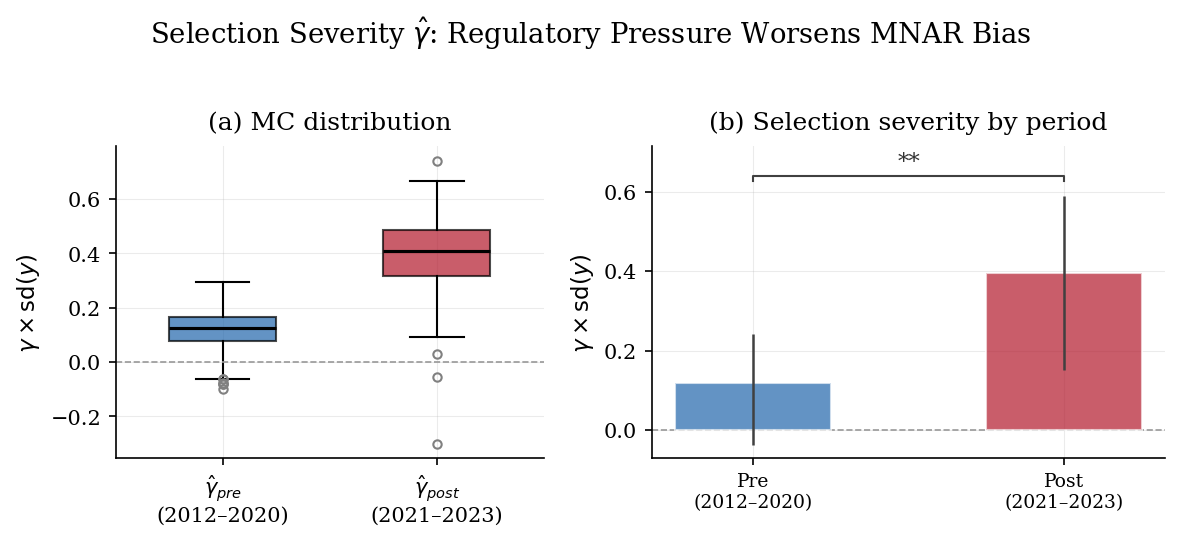

In [9]:
if HAS_INTERACTION:
    import matplotlib.pyplot as plt
    import numpy as np

    interaction_col = SPEC["interaction_col"]
    cutoff = SPEC["interaction_cutoff"]

    params_df = pd.DataFrame(mc_results["lm_params"].tolist())

    # Scale by sd of the SAME variable the coefficient multiplies: the regressor is
    # sc1_disclosed_complete, so γ is "log-odds per sd of the completed vector".
    # df["sc1_disclosed"].std() is the disclosed-only sd and is larger (non-disclosers
    # are smaller emitters); using it inflates γ.
    # Use the mean across draws as a FIXED yardstick rather than scaling per draw:
    # sd_y swings ~2x across draws (levels are heavy-tailed), and folding that noise
    # into γ inflates its spread without informing selection. A constant rescale also
    # preserves the t-statistic of the underlying per-tonne coefficient.
    sd_y = mc_results["sd_y_draw"].mean()                     # fixed sigma-bar

    gamma_base = params_df["sc1_disclosed_complete"] * sd_y   # γ_pre (full/baseline)
    gamma_post = gamma_base + params_df[interaction_col] * sd_y  # γ_post = base + interaction

    gamma_base = -gamma_base  # flip sign so that positive = more selection (worse MNAR bias)
    gamma_post = -gamma_post  # flip sign so that positive = more selection (w
    
    # ── Paired MC test on the deepening ──────────────────────────────
    # pre and post are computed from the SAME draws and share gamma_base, so
    # they're paired, not independent. The difference is just the (scaled)
    # interaction coefficient; test whether that distribution sits below 0.
    gamma_delta = params_df[interaction_col] * sd_y   # = gamma_post - gamma_base, per draw

    # Empirical one-sided MC p-value: fraction of draws with NO deepening (Δ >= 0).
    p_mc = float((gamma_delta >= 0).mean())

    def _stars(p):
        if p < 0.01:  return "***"
        if p < 0.05:  return "**"
        if p < 0.10:  return "*"
        return ""
    star_str = _stars(p_mc)

    print(f"γ_pre  (mean): {gamma_base.mean():.4f}  "
          f"[{gamma_base.quantile(0.025):.4f}, {gamma_base.quantile(0.975):.4f}]")
    print(f"γ_post (mean): {gamma_post.mean():.4f}  "
          f"[{gamma_post.quantile(0.025):.4f}, {gamma_post.quantile(0.975):.4f}]")
    print(f"Δ = γ_post − γ_pre (mean): {gamma_delta.mean():.4f}  "
          f"[{gamma_delta.quantile(0.025):.4f}, {gamma_delta.quantile(0.975):.4f}]")
    print(f"MC p-value (one-sided, H1: Δ<0): {p_mc:.4f}  -> '{star_str}'")

    fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), gridspec_kw={"width_ratios": [1, 1.2]})

    # ── Panel A: boxplot ─────────────────────────────────────────────
    data = [gamma_base.values, gamma_post.values]
    bp = axes[0].boxplot(
        data,
        labels=[r"$\hat{\gamma}_{pre}$" + "\n" + f"(2012\u2013{cutoff - 1})",
                r"$\hat{\gamma}_{post}$" + "\n" + f"({cutoff}\u2013{df['year'].max()})"],
        patch_artist=True, widths=0.5,
        medianprops=dict(color="black", lw=1.5),
        flierprops=dict(marker="o", markersize=4, markerfacecolor="none",
                        markeredgecolor="0.5", lw=0.8),
        whiskerprops=dict(lw=1.0),
        capprops=dict(lw=1.0),
    )
    bp["boxes"][0].set_facecolor("#2166ac"); bp["boxes"][0].set_alpha(0.7)
    bp["boxes"][1].set_facecolor("#b2182b"); bp["boxes"][1].set_alpha(0.7)

    axes[0].axhline(0, color="#999999", lw=0.8, ls="--")
    axes[0].set_ylabel(r"$\gamma \times \mathrm{sd}(y)$")
    axes[0].set_title("(a) MC distribution", pad=8)
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    # ── Panel B: pre vs post bars ────────────────────────────────────
    bar_means = [gamma_base.mean(), gamma_post.mean()]
    ci_lo = [gamma_base.quantile(0.025), gamma_post.quantile(0.025)]
    ci_hi = [gamma_base.quantile(0.975), gamma_post.quantile(0.975)]
    x = [0, 1]
    colors = ["#2166ac", "#b2182b"]

    # vlines expect (x, ymin, ymax); pass CI bounds, not the means
    axes[1].bar(x, bar_means, width=0.5, color=colors, alpha=0.7,
                edgecolor="white", zorder=3)
    axes[1].vlines(x, ci_lo, ci_hi, color="0.25", linewidth=1.2, zorder=4)
    axes[1].axhline(0, color="#999999", lw=0.8, ls="--")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(
        [f"Pre\n(2012\u2013{cutoff - 1})", f"Post\n({cutoff}\u2013{df['year'].max()})"],
        fontsize=9
    )
    axes[1].set_ylabel(r"$\gamma \times \mathrm{sd}(y)$")
    axes[1].set_title("(b) Selection severity by period", pad=8)
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

    # ── significance bracket: derived from the MC test, drawn over the bars ──
    if star_str:
        y_top = max(ci_hi)
        y_bot = min(min(ci_lo), 0.0)
        span  = y_top - y_bot
        y_br  = y_top + 0.08 * span          # bracket height
        h     = 0.02 * span                  # tick drop
        axes[1].plot([0, 0, 1, 1],
                     [y_br - h, y_br, y_br, y_br - h],
                     color="0.25", lw=1.0, zorder=5)
        axes[1].text(0.5, y_br + 0.01 * span, star_str,
                     ha="center", va="bottom", color="#333333", fontsize=11)
        axes[1].set_ylim(top=y_br + 0.12 * span)

    fig.suptitle(
        r"Selection Severity $\hat{\gamma}$: Regulatory Pressure Worsens MNAR Bias", y=1.02
    )
    fig.tight_layout()
    savepath = DIR_FIGURES / f"gamma_post_{TAG}.pdf"
    fig.savefig(savepath, bbox_inches="tight", dpi=300)
    print(f"Saved: gamma_post_{TAG}.pdf")
    plt.show()
else:
    print("No interaction term — skipping gamma pre/post plot.")

## Selection severity: pre vs. post interaction

This section only runs when `interaction_cutoff` is set.  
It compares the emissions selection coefficient ($\hat\gamma$) before and after the cutoff year, testing whether regulatory pressure worsens MNAR bias.

 year    gamma       se         pval
 2012 0.066726 0.032246 3.851953e-02
 2013 0.049726 0.037107 1.802152e-01
 2014 0.023914 0.038364 5.330628e-01
 2015 0.026295 0.041564 5.269742e-01
 2016 0.043363 0.043870 3.229351e-01
 2017 0.045056 0.047329 3.411026e-01
 2018 0.084698 0.045733 6.402578e-02
 2019 0.059668 0.049222 2.254242e-01
 2020 0.077416 0.058148 1.830642e-01
 2021 0.141775 0.052284 6.695602e-03
 2022 0.202276 0.046667 1.461144e-05
 2023 0.222345 0.044074 4.540758e-07
Saved: gamma_by_year_tilt_test.pdf


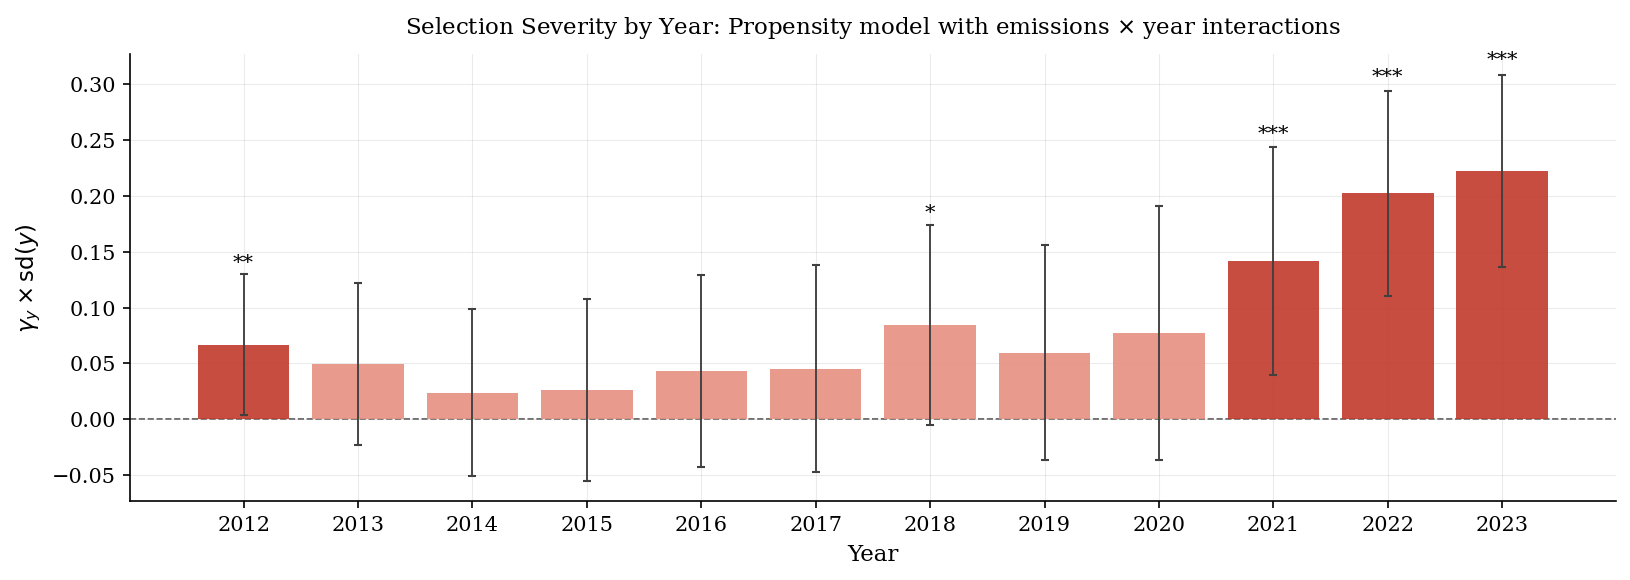

In [10]:
if RUN_YEARLY_GAMMA:
    import statsmodels.api as sm
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    # ── build design matrix on MC-averaged panel ──────────────────────
    panel = df_lm_avg.copy()
    panel["y_disc"] = panel["co2_bool"].astype(int)
    years_list = sorted(panel["year"].unique())

    # emissions × year-dummy interactions (one per year, no base)
    emis_cols = []
    for y in years_list:
        col = f"emis_{y}"
        panel[col] = panel["sc1_disclosed_complete"] * (panel["year"] == y).astype(int)
        emis_cols.append(col)

    # fixed effects: sector and year dummies (drop first for identification)
    sector_dummies = pd.get_dummies(
        panel[SPEC["sector_col"]], prefix="sec", drop_first=True
    ).astype(float)
    year_dummies = pd.get_dummies(
        panel["year"], prefix="yr", drop_first=True
    ).astype(float)

    X = pd.concat(
        [
            panel[["at"] + emis_cols].reset_index(drop=True).astype(float),
            sector_dummies.reset_index(drop=True),
            year_dummies.reset_index(drop=True),
        ],
        axis=1,
    )
    X = sm.add_constant(X)
    y = panel["y_disc"].values

    # ── fit one logit with all year×emissions interactions ────────────
    fit = sm.Logit(y, X.astype(float)).fit(disp=False, maxiter=200)

    # ── extract γ_y per year, scale by sd(sc1_disclosed) ──────────────
    # This fit uses df_lm_avg["sc1_disclosed_complete"] as the regressor, so γ must be
    # scaled by THAT vector's sd. Not the disclosed-only sd (~2x larger), and not a
    # per-draw sd (this is one fit on the MC-averaged panel, which is smoother).
    sd_y_global = panel["sc1_disclosed_complete"].std()
    gamma_rows = []
    for yr in years_list:
        col = f"emis_{yr}"
        coef = fit.params[col]
        se = fit.bse[col]
        pval = fit.pvalues[col]
        gamma_rows.append(
            {
                "year": int(yr),
                "gamma": coef * sd_y_global,
                "se": se * sd_y_global,
                "pval": pval,
            }
        )
    gamma_df = pd.DataFrame(gamma_rows)

    gamma_df['gamma'] = -gamma_df['gamma']  # flip sign so that positive = more selection (worse MNAR bias)

    print(gamma_df.to_string(index=False))

    # ── plot γ_y with 95% CIs, coloured by sign + significance ────────
    fig, ax = plt.subplots(figsize=(11, 4))
    yrs = gamma_df["year"].values
    coefs = gamma_df["gamma"].values
    ses = gamma_df["se"].values
    pvals = gamma_df["pval"].values

    # # shaded bands for key regulatory years
    # for y0, y1 in [(2019, 2019), (2022, 2023)]:
    #     ax.axvspan(y0 - 0.45, y1 + 0.45,
    #                 color="#FFF3A3", alpha=0.55, linewidth=0, zorder=0)

    colors = []
    for c, p in zip(coefs, pvals):
        if c < 0 and p < 0.05:
            colors.append("#1b4f8a")      # significant negative: MNAR
        elif c < 0:
            colors.append("#a8c4e0")      # insignificant negative
        elif c > 0 and p < 0.05:
            colors.append("#c0392b")      # significant positive (unusual)
        else:
            colors.append("#e69080")      # insignificant positive

    ax.bar(yrs, coefs, color=colors, edgecolor="none", alpha=0.9, zorder=2)
    ax.errorbar(yrs, coefs, yerr=1.96 * ses, fmt="none",
                ecolor="0.25", elinewidth=0.9, capsize=2, zorder=3)

    # significance stars
    for yr_, c, s, p in zip(yrs, coefs, ses, pvals):
        if p < 0.01:
            star = "***"
        elif p < 0.05:
            star = "**"
        elif p < 0.10:
            star = "*"
        else:
            star = ""
        if star:
            offset = (1.96 * s + abs(c) * 0.02) * (-1 if c < 0 else 1)
            va = "top" if c < 0 else "bottom"
            ax.text(yr_, c + offset, star, ha="center", va=va, fontsize=10)

    # regulatory labels
    # ymax_abs = max(abs(coefs - 1.96 * ses).max(), abs(coefs + 1.96 * ses).max()) * 1.25
    # ax.text(2019,   ymax_abs, "2019\nESG peak", fontsize=8.5,
    #         color="#b87d00", ha="center", va="top")
    # ax.text(2022.5, ymax_abs, "2022\nSEC/CSRD", fontsize=8.5,
    #         color="#b87d00", ha="center", va="top")

    ax.axhline(0, color="#555555", linewidth=0.8, linestyle="--", zorder=1)
    ax.set_xlabel("Year")
    ax.set_ylabel(r"$\gamma_y \times \mathrm{sd}(y)$")
    ax.set_title(
        "Selection Severity by Year: Propensity model with emissions $\\times$ year interactions",
        fontsize=11, pad=10
    )
    ax.set_xticks(yrs)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    legend_items = [
        Patch(color="#c0392b", label="Negative, significant at 5%"),
        Patch(color="#e69080", label="Negative, insignificant"),
        Patch(color="#a8c4e0", label="Positive, insignificant"),
        Patch(color="#1b4f8a", label="Positive, significant at 5%"),
        Patch(color="#FFF3A3", label="Key regulatory year"),
    ]
    # ax.legend(handles=legend_items, fontsize=9, framealpha=0.9, loc="best")

    plt.tight_layout()
    savepath = DIR_FIGURES / f"gamma_by_year_{TAG}.pdf"
    fig.savefig(savepath, bbox_inches="tight", dpi=300)
    print(f"Saved: gamma_by_year_{TAG}.pdf")
    plt.show()
else:
    print("run_yearly_gamma disabled in SPEC — skipping year-by-year gamma plot.")

In [11]:
# ── Cutoff-sensitivity (sup-Wald) scan for the structural break in γ ──
import statsmodels.api as sm
import numpy as np

full = df_lm_avg.copy()
full["y_disc"] = full["co2_bool"].astype(int)
sector_col = SPEC["sector_col"]
years = sorted(full["year"].unique())
# Same as cell 16: the scan fits on df_lm_avg, so scale by that panel's complete-vector
# sd. Only gamma_delta is affected -- wald/z/p are scale-invariant.
sd_y  = full["sc1_disclosed_complete"].std()

def scan(sample):
    p = full[full["year"].isin(sample)].copy()
    yrs = sorted(p["year"].unique())
    cands = [c for c in yrs if (min(yrs) + 2) <= c <= (max(yrs) - 1)]

    sec_d = pd.get_dummies(p[sector_col], prefix="sec", drop_first=True).astype(float)
    yr_d  = pd.get_dummies(p["year"],     prefix="yr",  drop_first=True).astype(float)
    base  = pd.concat([p[["at", "sc1_disclosed_complete"]].reset_index(drop=True).astype(float),
                       sec_d.reset_index(drop=True), yr_d.reset_index(drop=True)], axis=1)
    yv, emis, yrv = p["y_disc"].values, p["sc1_disclosed_complete"].values, p["year"].values

    rows = []
    for c in cands:
        X = base.copy()
        X["emis_x_post"] = emis * (yrv >= c)
        X = sm.add_constant(X)
        X = X.loc[:, (X.nunique() > 1) | (X.columns == "const")]   # drop all-zero cols
        fit = sm.Logit(yv, X.astype(float)).fit(disp=False, maxiter=200)
        b, se = fit.params["emis_x_post"], fit.bse["emis_x_post"]
        rows.append({"cutoff": int(c), "gamma_delta": b * sd_y,
                     "wald": (b / se) ** 2, "z": b / se,
                     "p_naive": fit.pvalues["emis_x_post"]})
    r = pd.DataFrame(rows)
    r["argmax"] = r["wald"] == r["wald"].max()
    return r

res = scan(years)
print("FULL SAMPLE\n", res.round(4).to_string(index=False))
print("sup-Wald break (argmax):", int(res.loc[res.wald.idxmax(), "cutoff"]), "\n")

res_no23 = scan([y_ for y_ in years if y_ != 2023])
print("DROP 2023\n", res_no23.round(4).to_string(index=False))
print("sup-Wald break (argmax):", int(res_no23.loc[res_no23.wald.idxmax(), "cutoff"]))


FULL SAMPLE
  cutoff  gamma_delta    wald       z  p_naive  argmax
   2014      -0.0172  0.3714 -0.6094   0.5423   False
   2015      -0.0396  2.3185 -1.5227   0.1278   False
   2016      -0.0566  4.9665 -2.2286   0.0258   False
   2017      -0.0685  7.2226 -2.6875   0.0072   False
   2018      -0.0840 10.1765 -3.1901   0.0014   False
   2019      -0.0920 11.0008 -3.3168   0.0009   False
   2020      -0.1186 16.1146 -4.0143   0.0001   False
   2021      -0.1407 21.2570 -4.6105   0.0000   False
   2022      -0.1566 21.2788 -4.6129   0.0000    True
sup-Wald break (argmax): 2022 

DROP 2023
  cutoff  gamma_delta    wald       z  p_naive  argmax
   2014      -0.0066  0.0533 -0.2309   0.8174   False
   2015      -0.0272  1.0514 -1.0254   0.3052   False
   2016      -0.0424  2.6359 -1.6235   0.1045   False
   2017      -0.0522  3.8858 -1.9712   0.0487   False
   2018      -0.0655  5.5493 -2.3557   0.0185   False
   2019      -0.0697  5.2966 -2.3014   0.0214   False
   2020      -0.0959  7.82

## Sectoral heterogeneity in $\hat\gamma$

Fits the propensity model **separately on each `gsector` subsample**
(constant, size, emissions, emissions × post, year FE) and extracts the
post-cutoff selection coefficient $\hat\gamma_{post} = \hat\beta_{\mathrm{emis}} + \hat\beta_{\mathrm{emis \times post}}$ for each sector.


Two clean diagnostics that replace the pre/post + regulatory-tier plots:

1. **Sector γ (descriptive)** — one emissions slope per sector over the *whole* window. Negative γ = higher emitters disclose less ("silence"). Sorted, colored by sign × significance only. Shows *where* silence concentrates.
2. **IO γ (mechanism test)** — within each sector, split firms into institutional-ownership terciles and estimate one emissions slope per tercile, with sector + year + tercile FE. The formal test is **γ(High IO) − γ(Low IO)**: negative ⇒ silence is *more selective* among high-ownership firms (investor-pressure channel). Within-sector design nets out sector composition.

**SE caveat:** both are single fits on the MC-averaged panel (`df_lm_avg`), so CIs are *conditional on the imputed panel*. For publication SEs, re-estimate inside the MC loop (one fit per draw) and combine across draws.


gamma_s: selection severity per +1 within-sector SD of emissions (POSITIVE => strategic silence). exp(-gamma) = odds ratio of disclosure.

          sector   gamma  pval      lo      hi  odds_ratio  disc_rate  saturated
     Real Estate 203.148 0.000 115.465 290.830       0.000      0.033       True
      Financials   8.106 0.000   4.559  11.654       0.000      0.065       True
   Communication   2.862 0.000   1.994   3.729       0.057      0.074       True
          Energy   1.941 0.000   1.574   2.309       0.144      0.165      False
     Health Care   0.906 0.000   0.773   1.038       0.404      0.056       True
              IT   0.650 0.000   0.520   0.780       0.522      0.111      False
       Utilities   0.285 0.023   0.039   0.531       0.752      0.345      False
     Industrials   0.104 0.020   0.016   0.191       0.901      0.180      False
       Materials  -0.037 0.648  -0.198   0.123       1.038      0.271      False
  Consumer Discr  -0.198 0.000  -0.272  -0.124     

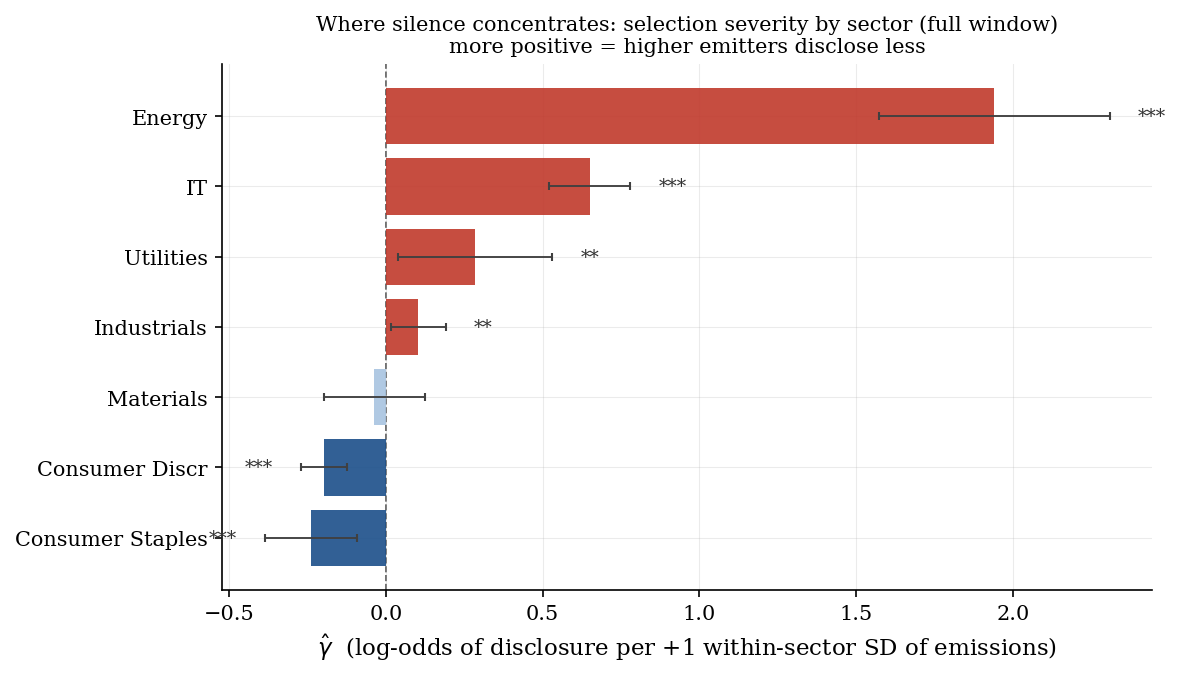

In [12]:
# ============================================================
# Full-window sectoral selection severity  (descriptive)
# ------------------------------------------------------------
# gamma_s = emissions slope in the disclosure logit, per sector,
#           over the WHOLE window (no pre/post, no tiers).
#   negative gamma_s -> higher emitters in sector s disclose LESS ("silence")
#   emissions z-scored WITHIN sector -> gamma is "log-odds of disclosure
#   per +1 within-sector SD of emissions"; exp(gamma) is the odds ratio.
# SE caveat: single fit on the MC-averaged panel (df_lm_avg) -> CIs are
# conditional on the imputed panel. For publication SEs, re-fit per MC draw.
# ============================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

sector_col = SPEC["sector_col"]

p = df_lm_avg.copy()
p["y_disc"] = p["co2_bool"].astype(int)
p["z_emis"] = p.groupby(sector_col)["sc1_disclosed_complete"].transform(
    lambda x: (x - x.mean()) / (x.std(ddof=0) if x.std(ddof=0) > 0 else 1.0)
)

secs = sorted(p[sector_col].dropna().unique())
for s in secs:
    p[f"z_{s}"] = p["z_emis"] * (p[sector_col] == s).astype(float)
z_cols = [f"z_{s}" for s in secs]

# Size enters with a SECTOR-SPECIFIC slope. A single common size coefficient is
# strongly rejected: fitting it per sector gives slopes spanning ~64x (2.0e-05 in
# Consumer Discretionary to 1.3e-03 in Real Estate). Size is the dominant driver of
# disclosure and is highly correlated with emissions, so a misspecified common slope
# gets absorbed by the very sector emissions slopes we are trying to read -- it flips
# the sign of gamma_s for Industrials and Consumer Staples. Free it.
for s in secs:
    p[f"at_{s}"] = p["at"] * (p[sector_col] == s).astype(float)
at_cols = [f"at_{s}" for s in secs]

X = pd.concat(
    [p[at_cols + z_cols].reset_index(drop=True).astype(float),
     pd.get_dummies(p[sector_col], prefix="sec", drop_first=True).astype(float).reset_index(drop=True),
     pd.get_dummies(p["year"],     prefix="yr",  drop_first=True).astype(float).reset_index(drop=True)],
    axis=1,
)
X = sm.add_constant(X)
fit = sm.Logit(p["y_disc"].values, X.astype(float)).fit(disp=False, maxiter=500)
if not fit.mle_retvals.get("converged", True):
    print("WARNING: sector logit did not converge.")

rate = p.groupby(sector_col)["y_disc"].mean()
SAT_LO, SAT_HI = 0.1, 1.00

rows = []
for s in secs:
    c = f"z_{s}"
    b, se, pv = fit.params[c], fit.bse[c], fit.pvalues[c]
    # Report in the MODEL's sign convention: the fitted coefficient is -gamma
    # (propensity is Lambda(f(x) - gamma*y)), so gamma > 0 == strategic silence.
    # Flip here, at the source, so lo/hi/odds_ratio/sort/colour all inherit it --
    # flipping downstream desynchronises the interval from the point estimate.
    g = -b
    rows.append(dict(sector=s, gamma=g, se=se, pval=pv,
                     lo=g - 1.96 * se, hi=g + 1.96 * se,
                     odds_ratio=np.exp(-g), disc_rate=rate.get(s, np.nan)))
sec_df = pd.DataFrame(rows)
sec_df["saturated"] = (sec_df["disc_rate"] < SAT_LO) | (sec_df["disc_rate"] > SAT_HI)
sec_df = sec_df.sort_values("gamma", ascending=False).reset_index(drop=True)

print("gamma_s: selection severity per +1 within-sector SD of emissions "
      "(POSITIVE => strategic silence). exp(-gamma) = odds ratio of disclosure.\n")
print(sec_df.drop(columns="se").round(3).to_string(index=False))
if sec_df["saturated"].any():
    print(f"\nExcluded (disclosure rate <{SAT_LO:.0%} or >{SAT_HI:.0%}, gamma not identified): "
          + ", ".join(map(str, sec_df.loc[sec_df["saturated"], "sector"])))

# ---- plot: sorted, colored by sign x significance (no tiers) ----
plot_df = sec_df[~sec_df["saturated"]].sort_values("gamma", ascending=False).reset_index(drop=True)
def _color(g, pv):
    if g > 0 and pv < 0.05: return "#c0392b"   # significant silence
    if g > 0:               return "#e69080"   # weak silence
    if g < 0 and pv < 0.05: return "#1b4f8a"   # significant reverse
    return "#a8c4e0"                           # weak reverse

def _stars(pv):
    return "***" if pv < 0.01 else "**" if pv < 0.05 else "*" if pv < 0.10 else ""

n = len(plot_df)
fig, ax = plt.subplots(figsize=(8, max(4, 0.45 * n + 1.5)))
yy = np.arange(n)
ax.barh(yy, plot_df["gamma"],
        color=[_color(g, pv) for g, pv in zip(plot_df["gamma"], plot_df["pval"])],
        alpha=0.9, zorder=2)
ax.errorbar(plot_df["gamma"], yy, xerr=1.96 * plot_df["se"], fmt="none",
            ecolor="0.25", elinewidth=0.9, capsize=2, zorder=3)
xpad = 0.03 * (ax.get_xlim()[1] - ax.get_xlim()[0])
for yi, (g, se, pv) in enumerate(zip(plot_df["gamma"], plot_df["se"], plot_df["pval"])):
    st = _stars(pv)
    if st:
        end = g + (1.96 * se if g >= 0 else -1.96 * se)
        ax.text(end + (xpad if g >= 0 else -xpad), yi, st,
                ha="left" if g >= 0 else "right", va="center", fontsize=9, color="0.2")
ax.axvline(0, color="#555555", lw=0.8, ls="--", zorder=1)
ax.set_yticks(yy)
ax.set_yticklabels(plot_df["sector"])
ax.invert_yaxis()
ax.set_xlabel(r"$\hat\gamma$  (log-odds of disclosure per +1 within-sector SD of emissions)")
ax.set_title("Where silence concentrates: selection severity by sector (full window)\n"
             "more positive = higher emitters disclose less", fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
sp = DIR_FIGURES / f"gamma_by_sector_fullwindow_{TAG}.pdf"
fig.savefig(sp, bbox_inches="tight", dpi=300)
print(f"\nSaved: {sp.name}")
plt.show()


gamma by within-sector institutional-ownership tercile (log-odds per +1 within-sector SD of emissions):

io_tercile     n  io_mean  gamma    se  pval     lo     hi
       Low 14104    0.208 -0.064 0.044 0.141 -0.150  0.021
       Mid 14100    0.683 -0.048 0.020 0.017 -0.087 -0.008
      High 14106    0.954  0.162 0.028 0.000  0.107  0.217

Mechanism test  gamma(High IO) - gamma(Low IO) = +0.226  (SE 0.052, p 0.000)
positive => silence is MORE selective among high institutional-ownership firms

Saved: gamma_by_io_fullwindow_tilt_test.pdf


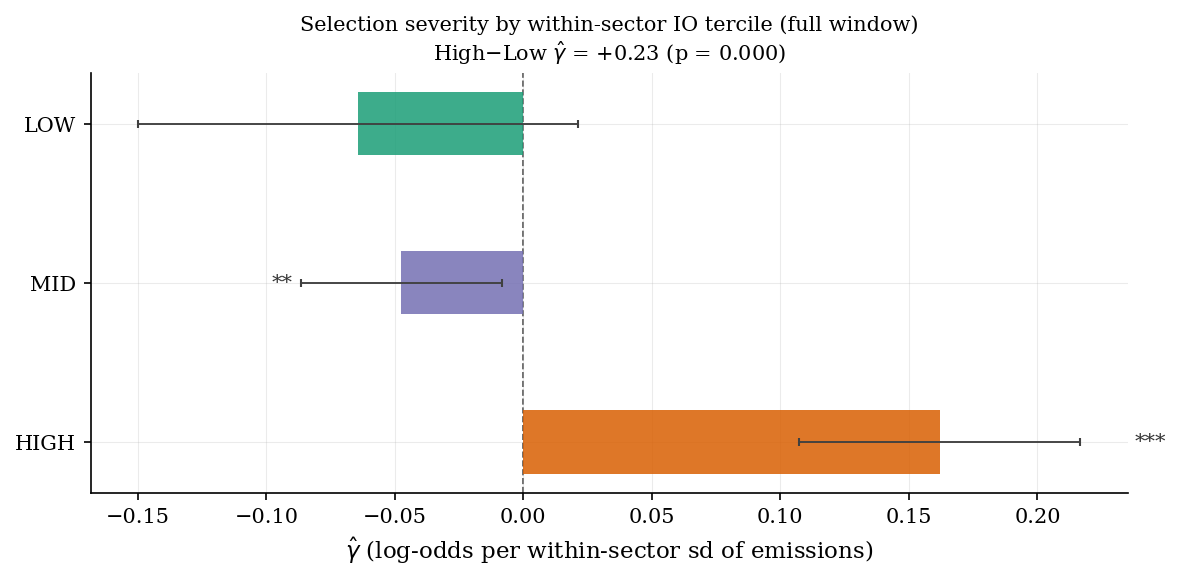

In [13]:
# ============================================================
# Full-window IO mechanism: within-sector institutional-ownership terciles
# ------------------------------------------------------------
# Within each sector, split firms into terciles of institutional
# ownership (io); estimate one emissions slope per tercile, with
# sector FE + year FE + IO-tercile FE. Whole window (no pre/post).
#
# Mechanism test:  gamma(High IO) - gamma(Low IO).
#   negative  => silence is MORE selective among high-IO firms.
# Same conditional-on-imputed-panel SE caveat as the sector cell.
# ============================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

sector_col = SPEC["sector_col"]
assert "gvkey" in df_lm_avg.columns, "df_lm_avg needs 'gvkey' to merge institutional ownership."

io_panel = pd.read_parquet("../data/processed/io_panel.parquet")
io_panel = io_panel.rename(columns={"fyear": "year"})
io_panel["gvkey"] = pd.to_numeric(io_panel["gvkey"], errors="coerce").astype("Int64")

q = df_lm_avg.copy()
q["gvkey"] = pd.to_numeric(q["gvkey"], errors="coerce").astype("Int64")
q = q.merge(io_panel[["gvkey", "year", "io"]], on=["gvkey", "year"], how="left")
q = q.dropna(subset=["io"]).copy()
q["y_disc"] = q["co2_bool"].astype(int)

# within-sector IO terciles (rank-based so qcut never fails on ties)
def _terc(x):
    if x.notna().sum() < 6:
        return pd.Series(np.nan, index=x.index, dtype="object")
    return pd.qcut(x.rank(method="first"), 3, labels=["Low", "Mid", "High"]).astype("object")

q["io_tercile"] = q.groupby(sector_col)["io"].transform(_terc)
q = q.dropna(subset=["io_tercile"]).copy()

q["z_emis"] = q.groupby(sector_col)["sc1_disclosed_complete"].transform(
    lambda x: (x - x.mean()) / (x.std(ddof=0) if x.std(ddof=0) > 0 else 1.0)
)

terciles = ["Low", "Mid", "High"]
for t in terciles:
    q[f"z_{t}"] = q["z_emis"] * (q["io_tercile"] == t).astype(float)
z_cols = [f"z_{t}" for t in terciles]

# Size enters with a TERCILE-SPECIFIC slope, mirroring the sector cell. Here the
# restriction happens to be nearly innocuous -- per-tercile slopes span only ~1.25x,
# because terciles are formed WITHIN sector and so hold production technology roughly
# fixed -- but we free it anyway so the ownership result does not rest on a restriction
# that is demonstrably fatal in the sector design.
for t in terciles:
    q[f"at_{t}"] = q["at"] * (q["io_tercile"] == t).astype(float)
at_cols = [f"at_{t}" for t in terciles]

X = pd.concat(
    [q[at_cols + z_cols].reset_index(drop=True).astype(float),
     pd.get_dummies(q[sector_col],   prefix="sec", drop_first=True).astype(float).reset_index(drop=True),
     pd.get_dummies(q["year"],       prefix="yr",  drop_first=True).astype(float).reset_index(drop=True),
     pd.get_dummies(q["io_tercile"], prefix="iot", drop_first=True).astype(float).reset_index(drop=True)],
    axis=1,
)
X = sm.add_constant(X)
fit_io = sm.Logit(q["y_disc"].values, X.astype(float)).fit(disp=False, maxiter=500)
cov = fit_io.cov_params()

rows = []
for t in terciles:
    c = f"z_{t}"
    b, se, pv = fit_io.params[c], fit_io.bse[c], fit_io.pvalues[c]
    g = -b   # model convention: gamma > 0 == strategic silence. Flip at the source.
    rows.append(dict(io_tercile=t, n=int((q["io_tercile"] == t).sum()),
                     io_mean=q.loc[q["io_tercile"] == t, "io"].mean(),
                     gamma=g, se=se, pval=pv, lo=g - 1.96 * se, hi=g + 1.96 * se))
io_df = pd.DataFrame(rows)

# mechanism test: High - Low
gH, gL = -fit_io.params["z_High"], -fit_io.params["z_Low"]   # model convention
var_d = cov.loc["z_High", "z_High"] + cov.loc["z_Low", "z_Low"] - 2 * cov.loc["z_High", "z_Low"]
se_d = np.sqrt(max(var_d, 0.0))
diff = gH - gL
z_d = diff / se_d if se_d > 0 else 0.0
p_d = 2 * (1 - stats.norm.cdf(abs(z_d)))

print("gamma by within-sector institutional-ownership tercile "
      "(log-odds per +1 within-sector SD of emissions):\n")
print(io_df.round(3).to_string(index=False))
print(f"\nMechanism test  gamma(High IO) - gamma(Low IO) = {diff:+.3f}  (SE {se_d:.3f}, p {p_d:.3f})")
print("positive => silence is MORE selective among high institutional-ownership firms")

# ---- plot (styled like the pre/post β-channel figure) ----
def _stars(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

COLORS = {"Low": "#1b9e77", "Mid": "#7570b3", "High": "#d95f02"}
g = io_df.set_index("io_tercile").loc[terciles]

fig, ax = plt.subplots(figsize=(8, 4))
y_pos = np.arange(len(terciles))
bar_w = 0.4

ax.barh(y_pos, g["gamma"], bar_w,
        color=[COLORS[t] for t in terciles],
        edgecolor="none", alpha=0.85, zorder=3,
        xerr=1.96 * g["se"],
        error_kw=dict(elinewidth=0.9, ecolor="0.25", capsize=2))

ax.axvline(0, color="#555555", lw=0.8, ls="--", zorder=1)
ax.set_yticks(y_pos)
ax.set_yticklabels([t.upper() for t in terciles])
ax.invert_yaxis()
ax.set_xlabel(r"$\hat\gamma$ (log-odds per within-sector sd of emissions)")
ax.set_title(
    "Selection severity by within-sector IO tercile (full window)\n"
    rf"High$-$Low $\hat\gamma$ = {diff:+.2f} (p = {p_d:.3f})",
    fontsize=10,
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# significance stars past the CI end
xlim = ax.get_xlim()
pad  = 0.03 * (xlim[1] - xlim[0])
for yi, t in enumerate(terciles):
    gp, sep, pv = g.loc[t, "gamma"], g.loc[t, "se"], g.loc[t, "pval"]
    st = _stars(pv)
    if not st:
        continue
    ci_end = gp + (1.96 * sep if gp >= 0 else -1.96 * sep)
    x_text = ci_end + (pad if gp >= 0 else -pad)
    ha     = "left" if gp >= 0 else "right"
    ax.text(x_text+0.009, yi, st, ha=ha, va="center", fontsize=10, color="0.2")

plt.tight_layout()
sp = DIR_FIGURES / f"gamma_by_io_fullwindow_{TAG}.pdf"
fig.savefig(sp, bbox_inches="tight", dpi=300)
print(f"\nSaved: {sp.name}")
plt.show()

## Diagnostic: why the sample is restricted to major exchanges

`02_merge_panel` runs with `filter_exchg=True`, keeping only NYSE / NYSE American /
Nasdaq (`exchg` 11, 12, 14) and dropping ~56k firm-years. That is the single most
aggressive sample choice in the paper, so the appendix has to show why it is there.

The cell below rebuilds the panel **without** the exchange filter, into a throwaway
frame — it never writes `panel_merged.parquet` and does not touch the baseline
pipeline — and reports two things:

1. **Coverage.** Firm-years, disclosers, and disclosure rate by exchange group.
   Off-exchange listings disclose at a rate near zero, so there is essentially no
   variation on the margin that identifies $\gamma$.
2. **What happens if you estimate $\gamma$ anyway.** One emissions slope per exchange
   group. The off-exchange estimate is a quasi-separation artifact — huge magnitude,
   huge standard error — and it drags the pooled estimate negative.

This is a *diagnostic*, not part of the pipeline. It uses a **single imputer fit**
rather than the full Monte Carlo: the argument rests on the disclosure rate, not on a
publication-grade $\hat\gamma$, and the off-exchange coefficient is not an estimate of
anything in the first place.

Output: `data/outputs/tables/diag_exchange_split.tex`.

In [14]:
# ============================================================
# Exchange-split diagnostic: why the baseline drops off-exchange listings
# ------------------------------------------------------------
# Reads the UNFILTERED panel (02 re-run with filter_exchg=False, written to
# all_empiricals_allexchg.parquet). Read-only: nothing here writes back into
# the baseline pipeline, and `df` / `df_lm_avg` above are untouched.
#
#   (A) coverage  -- firm-years, disclosers, disclosure rate by exchange group
#   (B) gamma     -- one emissions slope per exchange group, fit anyway, to show
#                    the off-exchange estimate is a quasi-separation artifact
#
# (B) uses a SINGLE imputer fit rather than the full MC. The argument rests on
# the disclosure rate in (A); the off-exchange coefficient is not an estimate of
# anything, so propagating imputation uncertainty through it would be theatre.
# ============================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm

ALLEXCH_PATH = DIR_PROC / "all_empiricals_allexchg.parquet"
MAJOR_CODES  = [11, 12, 14]          # NYSE, NYSE American, Nasdaq

if not ALLEXCH_PATH.exists():
    raise FileNotFoundError(
        f"{ALLEXCH_PATH.name} not found. Regenerate it by re-running 02_merge_panel with\n"
        "filter_exchg=False and 03_preprocess_data, writing to *_allexchg.parquet.\n"
        "Do NOT overwrite panel_merged.parquet / all_empiricals.parquet."
    )

dx = pd.read_parquet(ALLEXCH_PATH, engine="pyarrow")
# exchg is NaN for a handful of rows; NaN is not a major exchange, so it groups with Other.
dx["exch_group"] = np.where(dx["exchg"].isin(MAJOR_CODES), "Major", "Other")
GROUPS = ["Major", "Other"]

# ---------- (A) coverage of the disclosure margin ----------
cov = (dx.groupby("exch_group")
         .agg(firm_years=("co2_bool", "size"),
              firms=("gvkey", "nunique"),
              disclosers=("co2_bool", "sum"),
              disclosure_rate=("co2_bool", "mean"))
         .reindex(GROUPS))

print("(A) Disclosure margin by exchange group\n")
print(cov.assign(disclosure_rate=lambda t: (100 * t["disclosure_rate"]).round(3).astype(str) + "%")
         .to_string())
print(f"\n    Baseline keeps 'Major' only: {cov.loc['Major','firm_years']:,} of {len(dx):,} firm-years.")
print(f"    'Other' contributes {int(cov.loc['Other','disclosers'])} disclosers across "
      f"{cov.loc['Other','firm_years']:,} firm-years -> the margin identifying gamma is degenerate.")

# ---------- (B) fit gamma anyway, per exchange group ----------
# Rebuild the shift-share instrument exactly as in the baseline cell above.
p = dx.dropna(subset=["gsector", "gind", "at"]).sort_values(["gvkey", "year"]).copy()
p["log_wti"] = np.log(p["wti_crude"])
p["ppe_at"]  = p["ppegt"] / p["at"]
expo = p.groupby("gvkey")["ppe_at"].apply(lambda s: s.dropna().head(5).mean())
p["exposure"] = p["gvkey"].map(expo)
p = p.dropna(subset=["exposure"]).reset_index(drop=True)
lo_, hi_ = p["exposure"].quantile([0.01, 0.99])
p["exposure"] = p["exposure"].clip(lo_, hi_)
p["exposure"] = (p["exposure"] - p["exposure"].mean()) / p["exposure"].std()
p["z_wti"] = p["exposure"] * p["log_wti"]

from corporate_omissions.models.ols_lognormal_imputer import OLSLogNormalImputer
_imp = OLSLogNormalImputer()
p = _imp.fit_simulate(p, x_columns=SPEC["x_columns"], seed=1, n_draws=1,
                      draws_wide=False, print_summary=False)["df_full"]

p["y_disc"] = p["co2_bool"].astype(int)
p["z_emis"] = p.groupby("gsector")["sc1_disclosed_complete"].transform(
    lambda x: (x - x.mean()) / (x.std(ddof=0) if x.std(ddof=0) > 0 else 1.0)
)
for gname in GROUPS:
    p[f"z_{gname}"] = p["z_emis"] * (p["exch_group"] == gname).astype(float)

Xg = pd.concat(
    [p[["at"] + [f"z_{g}" for g in GROUPS]].reset_index(drop=True).astype(float),
     pd.get_dummies(p["gsector"],    prefix="sec", drop_first=True).astype(float).reset_index(drop=True),
     pd.get_dummies(p["year"],       prefix="yr",  drop_first=True).astype(float).reset_index(drop=True),
     pd.get_dummies(p["exch_group"], prefix="exg", drop_first=True).astype(float).reset_index(drop=True)],
    axis=1,
)
Xg = sm.add_constant(Xg)
Xg = Xg.loc[:, (Xg.nunique() > 1) | (Xg.columns == "const")]
fit_x = sm.Logit(p["y_disc"].values, Xg.astype(float)).fit(disp=False, maxiter=500)
converged = fit_x.mle_retvals.get("converged", True)

# pooled slope (single emissions term, no group split) for the contamination point
Xp = Xg.drop(columns=[f"z_{g}" for g in GROUPS])
Xp["z_emis"] = p["z_emis"].values.astype(float)
fit_p = sm.Logit(p["y_disc"].values, Xp.astype(float)).fit(disp=False, maxiter=500)

rows = []
for gname in GROUPS:
    c = f"z_{gname}"
    rows.append(dict(exch_group=gname,
                     n=int((p["exch_group"] == gname).sum()),
                     disclosers=int(p.loc[p["exch_group"] == gname, "y_disc"].sum()),
                     gamma=fit_x.params[c], se=fit_x.bse[c], pval=fit_x.pvalues[c]))
gx = pd.DataFrame(rows)

print("\n(B) Emissions slope by exchange group (log-odds per +1 within-sector SD)\n")
print(gx.round(3).to_string(index=False))
print(f"\n    Pooled (no split): gamma = {fit_p.params['z_emis']:+.3f} "
      f"(SE {fit_p.bse['z_emis']:.3f})")
if not converged:
    print("    NOTE: split logit did not converge -- itself a symptom of separation.")
print("\n    Read: 'Other' returns |gamma| ~ 13 -- an odds ratio of e^13 per SD, which is not\n"
      "    an economic magnitude but the numerical signature of a quasi-separated logit\n"
      "    fit to 7 disclosers. Note the pooled estimate is NOT dragged by it: with so\n"
      "    few disclosers the group contributes almost nothing to the emissions slope.\n"
      "    That is precisely the argument for dropping them. They cannot inform gamma,\n"
      "    yet including them would hand ~19k firm-years an imputed emissions level and\n"
      "    a tilt whose gamma and outcome model are extrapolated wholesale from firms\n"
      "    they have no disclosure behavior in common with.")

# ---------- LaTeX export ----------
def _f(x, d=3):
    return f"{x:,.{d}f}"

tex = r"""\begin{table}[htbp]
\small
\centering
\caption{\textbf{Why the sample is restricted to major exchanges.} Panel~A reports the
disclosure margin by exchange group on the panel built \emph{without} the exchange filter.
\emph{Major} is NYSE, NYSE American, and Nasdaq (Compustat \texttt{exchg} 11, 12, 14);
\emph{Other} is all remaining listings (OTC, pink-sheet, and foreign venues). Panel~B
reports the emissions slope estimated separately by group, with sector, year, and
exchange-group fixed effects, emissions standardized within sector. The \emph{Other}
estimate is reported to show what the restriction removes: with """ + str(int(cov.loc['Other','disclosers'])) + r""" disclosers in
""" + f"{int(cov.loc['Other','firm_years']):,}" + r""" firm-years the logit is quasi-separated, so the coefficient is a numerical
artifact rather than a measure of disclosure behavior. The pooled row shows that these
firms do not in fact distort the pooled slope -- with so few disclosers they barely enter
the likelihood -- which is itself the argument for excluding them: they cannot inform
$\gamma$, yet retaining them would assign 19{,}097 firm-years a tilt extrapolated entirely
from firms whose disclosure margin they do not share. Panel~B is a diagnostic of
identification, not an estimate: it uses a single imputer draw and standardizes emissions
within sector, so its magnitudes are not comparable to Table~\ref{tab:results_LM}.}
\label{tab:diag_exchange}
\begin{tabular}{lrrrr}
\toprule
\multicolumn{5}{l}{\emph{Panel A: disclosure margin}} \\
\midrule
Exchange group & Firm-years & Firms & Disclosers & Disclosure rate \\
\midrule
"""
for gname in GROUPS:
    r = cov.loc[gname]
    tex += (f"{gname} & {int(r['firm_years']):,} & {int(r['firms']):,} & "
            f"{int(r['disclosers']):,} & {100*r['disclosure_rate']:.3f}\\% \\\\\n")
tex += r"""\midrule
\multicolumn{5}{l}{\emph{Panel B: emissions slope, estimated by group}} \\
\midrule
Exchange group & \multicolumn{2}{r}{$\hat\gamma$} & \multicolumn{2}{r}{Std.\ error} \\
\midrule
"""
for _, r in gx.iterrows():
    tex += (f"{r['exch_group']} & \\multicolumn{{2}}{{r}}{{{-r['gamma']:+.3f}}} & "
            f"\\multicolumn{{2}}{{r}}{{{r['se']:.3f}}} \\\\\n")
tex += (f"Pooled & \\multicolumn{{2}}{{r}}{{{-fit_p.params['z_emis']:+.3f}}} & "
        f"\\multicolumn{{2}}{{r}}{{{fit_p.bse['z_emis']:.3f}}} \\\\\n")
tex += r"""\bottomrule
\end{tabular}
\end{table}
"""
out_tex = DIR_TABLES / "diag_exchange_split.tex"
out_tex.write_text(tex)
print(f"\nSaved: {out_tex.name}")

(A) Disclosure margin by exchange group

            firm_years  firms  disclosers disclosure_rate
exch_group                                               
Major            59388   7944        6920         11.652%
Other            21714   3629           7          0.032%

    Baseline keeps 'Major' only: 59,388 of 81,102 firm-years.
    'Other' contributes 7 disclosers across 21,714 firm-years -> the margin identifying gamma is degenerate.

(B) Emissions slope by exchange group (log-odds per +1 within-sector SD)

exch_group     n  disclosers   gamma    se  pval
     Major 51917        6724  -0.018 0.014 0.176
     Other 19097           7 -13.008 3.919 0.001

    Pooled (no split): gamma = -0.019 (SE 0.013)

    Read: 'Other' returns |gamma| ~ 13 -- an odds ratio of e^13 per SD, which is not
    an economic magnitude but the numerical signature of a quasi-separated logit
    fit to 7 disclosers. Note the pooled estimate is NOT dragged by it: with so
    few disclosers the group contrib

## Linking the two audience results: a triple difference

The IO-tercile cell above shows $\hat\gamma$ is steeper where institutional ownership is
higher (cross-section). The yearly-$\gamma$ and sup-Wald cells above show $\hat\gamma$ rises
after ~2020 (time series). As they stand these are two parallel facts, not one mechanism.

This cell links them. If the audience is what drives selection, the **post-2020 rise**
should be concentrated in the firms that **already had** the audience:

$$\mathrm{DDD} = \big[\hat\gamma_{\text{High,post}} - \hat\gamma_{\text{High,pre}}\big]
- \big[\hat\gamma_{\text{Low,post}} - \hat\gamma_{\text{Low,pre}}\big] > 0 .$$

Audience is the firm's **pre-period** ownership level, held fixed — not the change in
ownership, which would be caused by the disclosure behaviour being explained.

Pre-period audience available for 4,050 of 6,938 firms (41,079 of 51,355 obs, 80.0%).

gamma by pre-period audience x period (pre = <2020, audience fixed on 2017-2019 ownership):

audience period     n  io_pre_mean  gamma    se  pval     lo     hi
     Low    pre 14183        0.383 -0.206 0.032 0.000 -0.270 -0.143
     Low   post  6412        0.383 -0.147 0.055 0.007 -0.255 -0.040
    High    pre 14356        0.901  0.084 0.022 0.000  0.041  0.126
    High   post  6128        0.901  0.256 0.035 0.000  0.188  0.324

  DiD, High audience   +0.172  (SE 0.040, p 0.000)
  DiD, Low audience    +0.059  (SE 0.064, p 0.351)
  Triple difference    +0.113  (SE 0.075, z 1.52, p 0.130)
  positive => the post-2020 intensification of silence is concentrated in firms that already had a large institutional audience

Saved: gamma_ddd_audience_tilt_test.pdf


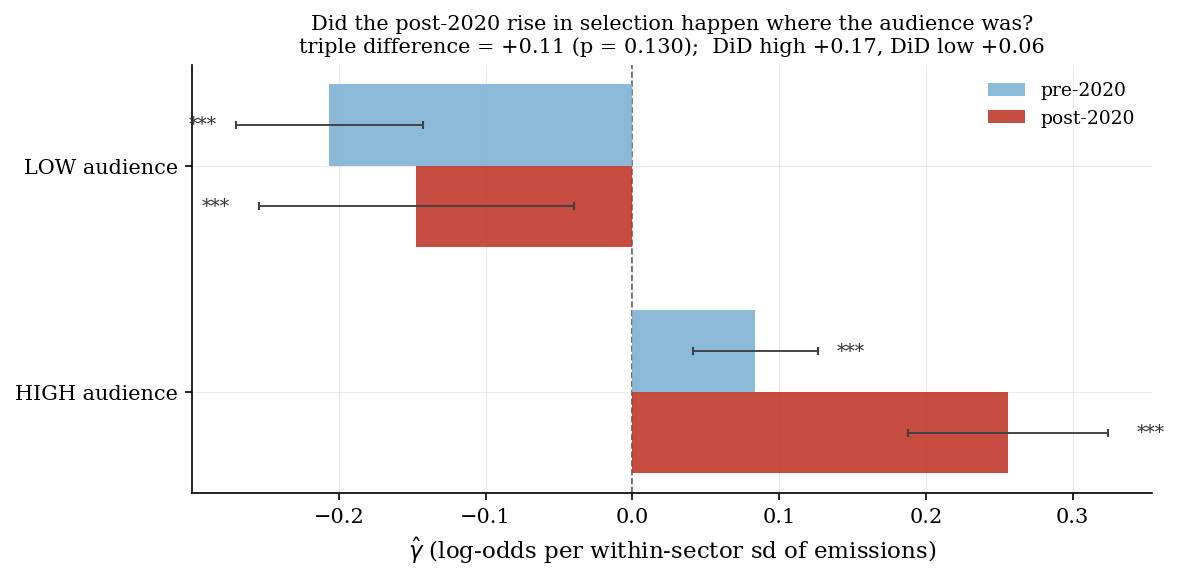

In [15]:
# ============================================================
# Triple difference: does the post-2020 rise in gamma happen
# where the audience already was?
# ------------------------------------------------------------
# The two audience results so far are parallel, not linked: gamma is steeper in
# high-institutional-ownership firms (cross-section), and gamma rises after
# ~2020 (time series). If both are the same mechanism, the RISE should be
# concentrated in the firms that already had the audience.
#
#   DDD = [g(High,post) - g(High,pre)] - [g(Low,post) - g(Low,pre)]
#   DDD > 0  =>  silence became more selective precisely where more
#                institutional capital was already watching.
#
# Audience is the firm's PRE-PERIOD ownership level (mean io over PRE_WINDOW),
# held fixed. Deliberately not the post-2020 CHANGE in ownership: green and
# institutional money flows toward firms that disclose, so a change measure is
# caused by the outcome and the DiD would be circular. A pre-2020 level cannot
# be moved by post-2020 disclosure.
#
# Reading the estimate:
#   - year FE absorb the common post-2020 shift, so the DDD is identified purely
#     off the differential between audience groups.
#   - the split is WITHIN sector, so this is not sector composition.
#   - requires firms observed in PRE_WINDOW, which drops later entrants; the
#     retained share is printed below and belongs in any writeup.
#   - same conditional-on-imputed-panel SE caveat as the sector and IO cells.
# ============================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

PRE_WINDOW = (2017, 2019)   # years used to fix the pre-period audience
POST_YEAR  = 2020           # first "post" year (BlackRock/Big-Three climate turn)

sector_col = SPEC["sector_col"]
assert "gvkey" in df_lm_avg.columns, "df_lm_avg needs 'gvkey' to merge institutional ownership."

d = df_lm_avg.copy()
if "year" not in d.columns:
    d = d.rename(columns={"fyear": "year"})
d["gvkey"] = pd.to_numeric(d["gvkey"], errors="coerce").astype("Int64")

io_panel = pd.read_parquet("../data/processed/io_panel.parquet")
io_panel = io_panel.rename(columns={"fyear": "year"})
io_panel["gvkey"] = pd.to_numeric(io_panel["gvkey"], errors="coerce").astype("Int64")

# predetermined audience: average ownership over the pre-window, one number per firm
io_pre = (io_panel[io_panel["year"].between(*PRE_WINDOW)]
          .groupby("gvkey", as_index=False)["io"].mean()
          .rename(columns={"io": "io_pre"}))

q = d.merge(io_pre, on="gvkey", how="left")
n_all, f_all = len(q), q["gvkey"].nunique()
q = q.dropna(subset=["io_pre"]).copy()
q["io_pre"] = q["io_pre"].astype(float)
print(f"Pre-period audience available for {q['gvkey'].nunique():,} of {f_all:,} firms "
      f"({len(q):,} of {n_all:,} obs, {len(q)/n_all:.1%}).")

q["y_disc"] = q["co2_bool"].astype(int)
q["post"]   = (q["year"] >= POST_YEAR).astype(int)

# within-sector High/Low audience (median split -- halves, not terciles: the DDD
# already splits the sample four ways and terciles would leave no power)
def _half(x):
    if x.notna().sum() < 6:
        return pd.Series(np.nan, index=x.index, dtype="object")
    return pd.Series(np.where(x > x.median(), "High", "Low"), index=x.index, dtype="object")

q["aud"] = q.groupby(sector_col)["io_pre"].transform(_half)
q = q.dropna(subset=["aud"]).copy()

q["z_emis"] = q.groupby(sector_col)["sc1_disclosed_complete"].transform(
    lambda x: (x - x.mean()) / (x.std(ddof=0) if x.std(ddof=0) > 0 else 1.0)
)

# one emissions slope per (audience x period) cell, and -- as in the sector and
# IO cells -- a size slope freed the same way, so a misspecified common size
# coefficient cannot leak into the emissions slopes we are reading.
cells = [("Low", 0), ("Low", 1), ("High", 0), ("High", 1)]
zname = {c: f"z_{c[0]}_{'post' if c[1] else 'pre'}" for c in cells}
for c, zc in zname.items():
    sel = ((q["aud"] == c[0]) & (q["post"] == c[1])).astype(float)
    q[zc] = q["z_emis"] * sel
    q[zc.replace("z_", "at_", 1)] = q["at"] * sel
z_cols  = list(zname.values())
at_cols = [c.replace("z_", "at_", 1) for c in z_cols]

X = pd.concat(
    [q[at_cols + z_cols].reset_index(drop=True).astype(float),
     pd.get_dummies(q[sector_col], prefix="sec", drop_first=True).astype(float).reset_index(drop=True),
     pd.get_dummies(q["year"],     prefix="yr",  drop_first=True).astype(float).reset_index(drop=True),
     pd.get_dummies(q["aud"],      prefix="aud", drop_first=True).astype(float).reset_index(drop=True)],
    axis=1,
)
X = sm.add_constant(X)
fit_ddd = sm.Logit(q["y_disc"].values, X.astype(float)).fit(disp=False, maxiter=500)
if not fit_ddd.mle_retvals.get("converged", True):
    print("WARNING: DDD logit did not converge.")
cov = fit_ddd.cov_params()

rows = []
for c, zc in zname.items():
    b, se, pv = fit_ddd.params[zc], fit_ddd.bse[zc], fit_ddd.pvalues[zc]
    g = -b   # model convention: propensity is Lambda(f(x) - gamma*y), so gamma > 0
             # == strategic silence. Flip at the source, as in the sector/IO cells.
    rows.append(dict(audience=c[0], period="post" if c[1] else "pre",
                     n=int(((q["aud"] == c[0]) & (q["post"] == c[1])).sum()),
                     io_pre_mean=q.loc[q["aud"] == c[0], "io_pre"].mean(),
                     gamma=g, se=se, pval=pv, lo=g - 1.96 * se, hi=g + 1.96 * se))
ddd_df = pd.DataFrame(rows)

# contrasts off the full covariance matrix (weights are on the fitted -gamma, so
# every weight flips sign once when converting to the gamma convention)
def _contrast(w):
    est = -sum(v * fit_ddd.params[k] for k, v in w.items())
    var = sum(w[a] * w[b] * cov.loc[a, b] for a in w for b in w)
    se_ = np.sqrt(max(var, 0.0))
    z_  = est / se_ if se_ > 0 else 0.0
    return est, se_, z_, 2 * (1 - stats.norm.cdf(abs(z_)))

zH1, zH0 = zname[("High", 1)], zname[("High", 0)]
zL1, zL0 = zname[("Low", 1)],  zname[("Low", 0)]
did_hi = _contrast({zH1: 1.0, zH0: -1.0})
did_lo = _contrast({zL1: 1.0, zL0: -1.0})
ddd    = _contrast({zH1: 1.0, zH0: -1.0, zL1: -1.0, zL0: 1.0})

print(f"\ngamma by pre-period audience x period (pre = <{POST_YEAR}, "
      f"audience fixed on {PRE_WINDOW[0]}-{PRE_WINDOW[1]} ownership):\n")
print(ddd_df.round(3).to_string(index=False))
print(f"\n  DiD, High audience   {did_hi[0]:+.3f}  (SE {did_hi[1]:.3f}, p {did_hi[3]:.3f})")
print(f"  DiD, Low audience    {did_lo[0]:+.3f}  (SE {did_lo[1]:.3f}, p {did_lo[3]:.3f})")
print(f"  Triple difference    {ddd[0]:+.3f}  (SE {ddd[1]:.3f}, z {ddd[2]:.2f}, p {ddd[3]:.3f})")
print("  positive => the post-2020 intensification of silence is concentrated in "
      "firms that already had a large institutional audience")

# ---- plot: four cells, grouped by audience ----
def _stars(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

COLORS = {"pre": "#7fb3d5", "post": "#c0392b"}
g = ddd_df.set_index(["audience", "period"])
groups = ["Low", "High"]
periods = ["pre", "post"]

fig, ax = plt.subplots(figsize=(8, 4))
y_pos = np.arange(len(groups))
bar_w = 0.36

for j, per in enumerate(periods):
    vals = [g.loc[(a, per), "gamma"] for a in groups]
    errs = [1.96 * g.loc[(a, per), "se"] for a in groups]
    off  = (j - 0.5) * bar_w
    ax.barh(y_pos + off, vals, bar_w, color=COLORS[per], edgecolor="none",
            alpha=0.9, zorder=3, label=f"{'pre' if per=='pre' else 'post'}-{POST_YEAR}",
            xerr=errs, error_kw=dict(elinewidth=0.9, ecolor="0.25", capsize=2))
    xlim = ax.get_xlim()
    pad = 0.03 * (xlim[1] - xlim[0])
    for yi, a in enumerate(groups):
        gv, sev, pv = g.loc[(a, per), ["gamma", "se", "pval"]]
        st = _stars(pv)
        if not st:
            continue
        ci_end = gv + (1.96 * sev if gv >= 0 else -1.96 * sev)
        ax.text(ci_end + (pad if gv >= 0 else -pad), y_pos[yi] + off, st,
                ha="left" if gv >= 0 else "right", va="center", fontsize=9, color="0.2")

ax.axvline(0, color="#555555", lw=0.8, ls="--", zorder=1)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{a.upper()} audience" for a in groups])
ax.invert_yaxis()
ax.set_xlabel(r"$\hat\gamma$ (log-odds per within-sector sd of emissions)")
ax.set_title(
    "Did the post-2020 rise in selection happen where the audience was?\n"
    rf"triple difference = {ddd[0]:+.2f} (p = {ddd[3]:.3f});  "
    rf"DiD high {did_hi[0]:+.2f}, DiD low {did_lo[0]:+.2f}",
    fontsize=10,
)
ax.legend(frameon=False, fontsize=9, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
sp = DIR_FIGURES / f"gamma_ddd_audience_{TAG}.pdf"
fig.savefig(sp, bbox_inches="tight", dpi=300)
print(f"\nSaved: {sp.name}")
plt.show()

## Falsification: does the ownership gradient need something to hide?

The IO cell established that $\hat\gamma$ is steeper in high-ownership firms. That alone
does not identify an *audience* — ownership tracks size, liquidity, index membership and
disclosure capacity, any of which would produce the same gradient with no audience
involved.

This cell separates the two readings by asking **when** the gradient appears:

| | ownership gradient among brown firms | among clean firms |
|---|---|---|
| audience mechanism | present | absent |
| size / capacity confound | present | present |

An audience can only penalise silence when the silence conceals something, so the
gradient should be conditional on there being bad news. A confound is unconditional.

Brownness is measured **only from observed data** — industry carbon intensity revealed by
disclosers, and firm PP&E intensity. Using `sc1_disclosed_complete` to define "brown"
would condition on the output of the very model that produces $\hat\gamma$.

gamma = log-odds of silence per SD of emissions (positive = strategic silence)

--- brown = industry carbon intensity (disclosers only)  (n = 40,792) ---
    LowIO   clean  gamma +0.071 (SE 0.048, p 0.137)  n=10,572
    LowIO   brown  gamma -0.140 (SE 0.034, p 0.000)  n=9,788
    HighIO  clean  gamma -0.076 (SE 0.026, p 0.003)  n=10,952
    HighIO  brown  gamma +0.085 (SE 0.031, p 0.006)  n=9,480
    [within-cell z  ] IO gap | brown +0.225 (p 0.000) | clean -0.147 (p 0.007) | DDD +0.372 (SE 0.070, p 0.000)
    [within-sector z] IO gap | brown +0.327 (p 0.000) | clean -0.063 (p 0.584) | DDD +0.389 (SE 0.119, p 0.001)

--- brown = firm PP&E intensity  (n = 41,287) ---
    LowIO   clean  gamma +0.135 (SE 0.048, p 0.005)  n=10,426
    LowIO   brown  gamma -0.042 (SE 0.032, p 0.185)  n=10,110
    HighIO  clean  gamma +0.088 (SE 0.028, p 0.002)  n=10,222
    HighIO  brown  gamma +0.196 (SE 0.033, p 0.000)  n=10,529
    [within-cell z  ] IO gap | brown +0.238 (p 0.000) | clean -0.047 (p 0.401

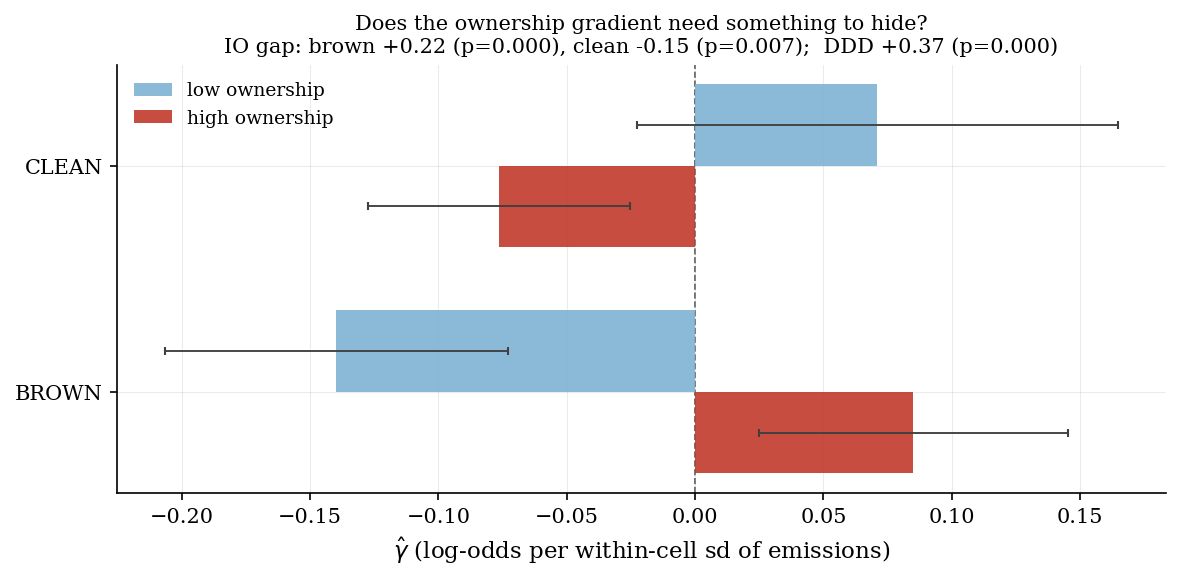

In [16]:
# ============================================================
# Does the ownership gradient in gamma appear only where there is
# something to hide?
# ------------------------------------------------------------
# The IO cell above shows gamma is steeper in high-ownership firms. That fact on
# its own does not identify an audience: ownership tracks size, liquidity, index
# membership and disclosure capacity, and any of those produces an ownership
# gradient in disclosure with no audience doing any work.
#
# This cell is the falsification. An audience can only punish silence when the
# silence is hiding something, so:
#
#   audience story      -> the ownership gradient in gamma appears among BROWN
#                          firms and is absent among clean ones
#   size/capacity story -> the gradient appears everywhere, brown or clean
#
#   DDD = [g(HighIO,brown) - g(LowIO,brown)] - [g(HighIO,clean) - g(LowIO,clean)]
#   DDD > 0 supports the audience reading; DDD ~ 0 with a positive gradient in
#   BOTH halves supports the confound reading.
#
# Two design constraints, both learned the hard way:
#
# 1. BROWNNESS MUST BE OBSERVABLE, NOT RECOVERED. sc1_disclosed_complete is the
#    output of the same MNAR model that produces gamma, so conditioning on it
#    and then reading gamma conditions on the model's own output. Every proxy
#    below is built from reported or third-party data only. (The emissions
#    REGRESSOR is still the completed vector -- that is what gamma is defined
#    on. It is the conditioning variable that has to stay clean.)
#
# 2. EMISSIONS ARE Z-SCORED WITHIN CELL. Cells formed this way have very
#    different emissions dispersion, and a slope denominated in sector-wide SDs
#    is then read far outside the range a cell actually covers -- which inflates
#    both the coefficient and its SE and makes cross-cell contrasts
#    meaningless. Within-cell scaling asks the comparable question: per SD of
#    emissions ACTUALLY PRESENT in this group. Sector scaling is reported
#    alongside as a robustness column; disagreement between the two is a
#    warning about leverage, not a finding.
# ============================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt

sector_col = SPEC["sector_col"]
assert "gvkey" in df_lm_avg.columns, "df_lm_avg needs 'gvkey' to merge institutional ownership."

d = df_lm_avg.copy()
if "year" not in d.columns:
    d = d.rename(columns={"fyear": "year"})
d["gvkey"] = pd.to_numeric(d["gvkey"], errors="coerce").astype("Int64")

io_panel = pd.read_parquet("../data/processed/io_panel.parquet").rename(columns={"fyear": "year"})
io_panel["gvkey"] = pd.to_numeric(io_panel["gvkey"], errors="coerce").astype("Int64")

q = d.merge(io_panel[["gvkey", "year", "io"]], on=["gvkey", "year"], how="left")
q = q.dropna(subset=["io"]).copy()
q["io"] = q["io"].astype(float)
q["y_disc"] = q["co2_bool"].astype(int)

# ---- audience: within-sector ownership half -------------------------------
# Halves, not terciles: the design already splits four ways.
q["aud"] = q.groupby(sector_col)["io"].transform(
    lambda x: pd.Series(np.where(x > x.median(), "HighIO", "LowIO"), index=x.index))

# ---- brownness proxies, all from observed data ----------------------------
# (a) industry carbon intensity revealed by DISCLOSERS ONLY, assigned to every
#     firm in the industry. Uses no imputed value anywhere, and a firm's own
#     disclosure choice cannot move its industry's average.
disc = q[(q["co2_bool"] == 1) & (q["sc1_disclosed"] > 0) & (q["revt"] > 0)]
ind_ci = (disc.assign(ci=disc["sc1_disclosed"] / disc["revt"])
              .groupby("gind")["ci"].median().rename("ind_ci"))
q = q.merge(ind_ci, left_on="gind", right_index=True, how="left")

# (b) firm PP&E intensity -- physical-capital heaviness, reported, firm-level,
#     so it splits WITHIN industry rather than across.
q["ppe_int"] = q["ppegt"] / q["at"].replace(0, np.nan)

# NOT USED: vendor (Trucost) carbon intensity. Tempting as a third proxy, but
# vendor coverage is itself a function of disclosure -- conditioning on a
# non-missing Trucost estimate keeps a subsample in which disclosure is close to
# deterministic, which is selecting on the outcome. It also separates perfectly
# and the logit will not identify. Left out deliberately, not by oversight.

PROXIES = [("ind_ci",  "industry carbon intensity (disclosers only)", None),
           ("ppe_int", "firm PP&E intensity",                         sector_col)]


def fit_ddd(p, brown_col, split_within, zscope):
    """One 4-cell logit. Returns the four gammas and the contrasts."""
    p = p.dropna(subset=[brown_col]).copy()
    if split_within is None:                       # brown varies across sectors
        med = p[brown_col].median()
        p["brown"] = np.where(p[brown_col] > med, "brown", "clean")
    else:                                          # brown varies within sector
        p["brown"] = p.groupby(split_within)[brown_col].transform(
            lambda x: pd.Series(np.where(x > x.median(), "brown", "clean"), index=x.index))
    p = p.dropna(subset=["brown", "aud"]).copy()
    if len(p) < 500:
        return None

    key = [sector_col] if zscope == "sector" else [sector_col, "aud", "brown"]
    p["z"] = p.groupby(key)["sc1_disclosed_complete"].transform(
        lambda x: (x - x.mean()) / (x.std(ddof=0) if x.std(ddof=0) > 0 else 1.0))

    cells = [("LowIO", "clean"), ("LowIO", "brown"), ("HighIO", "clean"), ("HighIO", "brown")]
    nm = {c: f"z_{c[0]}_{c[1]}" for c in cells}
    for c, zc in nm.items():
        sel = ((p["aud"] == c[0]) & (p["brown"] == c[1])).astype(float)
        if sel.sum() < 100:
            return None
        p[zc] = p["z"] * sel
        p[zc.replace("z_", "at_", 1)] = p["at"] * sel

    blocks = [p[[c.replace("z_", "at_", 1) for c in nm.values()] + list(nm.values())]
              .reset_index(drop=True).astype(float),
              pd.get_dummies(p[sector_col], prefix="sec", drop_first=True).astype(float).reset_index(drop=True),
              pd.get_dummies(p["year"], prefix="yr", drop_first=True).astype(float).reset_index(drop=True),
              pd.get_dummies(p["aud"], prefix="aud", drop_first=True).astype(float).reset_index(drop=True)]
    # a brown dummy is collinear with the sector FE when brown is an industry
    # attribute; only add it when brownness actually varies inside a sector.
    if p.groupby(sector_col)["brown"].nunique().max() > 1:
        blocks.append(pd.get_dummies(p["brown"], prefix="brn", drop_first=True)
                      .astype(float).reset_index(drop=True))

    X = sm.add_constant(pd.concat(blocks, axis=1))
    try:
        f = sm.Logit(p["y_disc"].values, X.astype(float)).fit(disp=False, maxiter=500)
        cov = f.cov_params()
    except np.linalg.LinAlgError:   # separation in a thin cell
        return None

    def con(w):
        est = -sum(v * f.params[k] for k, v in w.items())
        se = np.sqrt(max(sum(w[a] * w[b] * cov.loc[a, b] for a in w for b in w), 0.0))
        z = est / se if se > 0 else 0.0
        return est, se, 2 * (1 - stats.norm.cdf(abs(z)))

    Hb, Hc = nm[("HighIO", "brown")], nm[("HighIO", "clean")]
    Lb, Lc = nm[("LowIO", "brown")], nm[("LowIO", "clean")]
    return dict(
        converged=f.mle_retvals.get("converged", True),
        gammas={c: (-f.params[zc], f.bse[zc], f.pvalues[zc], int(((p["aud"] == c[0]) & (p["brown"] == c[1])).sum()))
                for c, zc in nm.items()},
        gap_brown=con({Hb: 1.0, Lb: -1.0}),          # ownership gradient among brown
        gap_clean=con({Hc: 1.0, Lc: -1.0}),          # ownership gradient among clean
        ddd=con({Hb: 1.0, Lb: -1.0, Hc: -1.0, Lc: 1.0}),
        n=len(p))


results = {}
print("gamma = log-odds of silence per SD of emissions (positive = strategic silence)\n")
for col, label, within in PROXIES:
    for zscope in ("cell", "sector"):
        r = fit_ddd(q, col, within, zscope)
        if r is None:
            print(f"[skipped: {label}, {zscope}-scaled -- too few observations]")
            continue
        results[(col, zscope)] = r
        if zscope == "cell":
            print(f"--- brown = {label}  (n = {r['n']:,}) ---")
            for c in [("LowIO", "clean"), ("LowIO", "brown"), ("HighIO", "clean"), ("HighIO", "brown")]:
                g, se, pv, n = r["gammas"][c]
                print(f"    {c[0]:<7} {c[1]:<6} gamma {g:+.3f} (SE {se:.3f}, p {pv:.3f})  n={n:,}")
        tag = "within-cell z" if zscope == "cell" else "within-sector z"
        print(f"    [{tag:<15}] IO gap | brown {r['gap_brown'][0]:+.3f} (p {r['gap_brown'][2]:.3f})"
              f" | clean {r['gap_clean'][0]:+.3f} (p {r['gap_clean'][2]:.3f})"
              f" | DDD {r['ddd'][0]:+.3f} (SE {r['ddd'][1]:.3f}, p {r['ddd'][2]:.3f})")
    print()

print("Reading: DDD > 0 means the ownership gradient in gamma is concentrated in brown")
print("firms -- the audience only bites when there is bad news. A positive gradient of")
print("similar size in BOTH halves instead points at size/visibility, not an audience.")

# ---- plot the primary proxy, within-cell scaling ----
PRIMARY = ("ind_ci", "cell")
if PRIMARY in results:
    r = results[PRIMARY]
    COLORS = {"LowIO": "#7fb3d5", "HighIO": "#c0392b"}
    order = ["clean", "brown"]

    def _stars(p):
        if p < 0.01: return "***"
        if p < 0.05: return "**"
        if p < 0.10: return "*"
        return ""

    fig, ax = plt.subplots(figsize=(8, 4))
    y_pos = np.arange(len(order))
    bar_w = 0.36
    for j, a in enumerate(["LowIO", "HighIO"]):
        vals = [r["gammas"][(a, b)][0] for b in order]
        errs = [1.96 * r["gammas"][(a, b)][1] for b in order]
        off = (j - 0.5) * bar_w
        ax.barh(y_pos + off, vals, bar_w, color=COLORS[a], edgecolor="none", alpha=0.9,
                zorder=3, label="low ownership" if a == "LowIO" else "high ownership",
                xerr=errs, error_kw=dict(elinewidth=0.9, ecolor="0.25", capsize=2))
    ax.axvline(0, color="#555555", lw=0.8, ls="--", zorder=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([b.upper() for b in order])
    ax.invert_yaxis()
    ax.set_xlabel(r"$\hat\gamma$ (log-odds per within-cell sd of emissions)")
    ax.set_title("Does the ownership gradient need something to hide?\n"
                 rf"IO gap: brown {r['gap_brown'][0]:+.2f} (p={r['gap_brown'][2]:.3f}), "
                 rf"clean {r['gap_clean'][0]:+.2f} (p={r['gap_clean'][2]:.3f});  "
                 rf"DDD {r['ddd'][0]:+.2f} (p={r['ddd'][2]:.3f})", fontsize=10)
    ax.legend(frameon=False, fontsize=9, loc="best")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # significance stars past the CI end, as in the sector and IO-tercile cells
    xlim = ax.get_xlim()
    ax.set_xlim(xlim[0] - 0.06 * (xlim[1] - xlim[0]),
                xlim[1] + 0.06 * (xlim[1] - xlim[0]))
    xlim = ax.get_xlim()
    pad = 0.02 * (xlim[1] - xlim[0])
    for j, a in enumerate(["LowIO", "HighIO"]):
        off = (j - 0.5) * bar_w
        for yi, b in enumerate(order):
            gp, sep, pv, _ = r["gammas"][(a, b)]
            st = _stars(pv)
            if not st:
                continue
            ci_end = gp + (1.96 * sep if gp >= 0 else -1.96 * sep)
            ax.text(ci_end + (pad if gp >= 0 else -pad), yi + off, st,
                    ha="left" if gp >= 0 else "right", va="center",
                    fontsize=10, color="0.2")

    plt.tight_layout()
    sp = DIR_FIGURES / f"gamma_audience_x_brown_{TAG}.pdf"
    fig.savefig(sp, bbox_inches="tight", dpi=300)
    print(f"\nSaved: {sp.name}")
    plt.show()

# ---- appendix table: both proxies x both standardisation conventions ----
COLS = [c for c in [("ind_ci","cell"),("ind_ci","sector"),("ppe_int","cell"),("ppe_int","sector")]
        if c in results]
if len(COLS) == 4:
    def _st(pv):
        return "$^{***}$" if pv < .01 else "$^{**}$" if pv < .05 else "$^{*}$" if pv < .10 else ""

    def _row(lab, get):
        v = [get(results[c]) for c in COLS]
        return [lab + " & " + " & ".join(f"{e:+.3f}{_st(pv)}" for e, se, pv in v) + r" \\",
                " & " + " & ".join(f"({se:.3f})" for e, se, pv in v) + r" \\"]

    CELLS = [("Low IO, clean", ("LowIO","clean")), ("Low IO, brown", ("LowIO","brown")),
             ("High IO, clean", ("HighIO","clean")), ("High IO, brown", ("HighIO","brown"))]
    tex = [r"\begin{table}[htbp]", r"\footnotesize\centering",
        r"\caption{\textbf{The ownership gradient by brownness: proxy and standardisation robustness.}",
        r"Estimated $\hat\gamma$ in each cell of a within-sector institutional-ownership split crossed with a",
        r"brownness split, and the contrasts built from them. Columns~(1)--(2) define brownness by the carbon",
        r"intensity of a firm's GICS industry, computed from disclosing firms only; columns~(3)--(4) use the",
        r"firm's own PP\&E intensity. Within-cell standardisation expresses $\hat\gamma$ per standard deviation",
        r"of emissions present in that cell; within-sector standardisation uses the sector-wide standard",
        r"deviation throughout. All specifications include sector, year and ownership fixed effects and free",
        r"the size slope across cells.}", r"\label{tab:gamma_brown_robustness}",
        r"\begin{tabular}{lcccc}", r"\toprule",
        r" & \multicolumn{2}{c}{Industry carbon intensity} & \multicolumn{2}{c}{Firm PP\&E intensity} \\",
        r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}",
        r" & (1) & (2) & (3) & (4) \\",
        r" & within cell & within sector & within cell & within sector \\", r"\midrule",
        r"\multicolumn{5}{l}{\emph{Panel A: $\hat\gamma$ by ownership-by-brownness cell}} \\[2pt]"]
    for lab, key in CELLS:
        tex += _row(lab, lambda r, k=key: (r["gammas"][k][0], r["gammas"][k][1], r["gammas"][k][2]))
    tex += [r"\midrule", r"\multicolumn{5}{l}{\emph{Panel B: contrasts}} \\[2pt]"]
    for lab, k in [("Ownership gap, brown","gap_brown"), ("Ownership gap, clean","gap_clean"),
                   ("Triple difference","ddd")]:
        tex += _row(lab, lambda r, k=k: r[k])
    tex += [r"\midrule",
        "Observations & " + " & ".join(f"{results[c]['n']:,}" for c in COLS) + r" \\",
        r"\bottomrule", r"\end{tabular}", r"\begin{flushleft}\footnotesize",
        r"\textit{Notes:} The triple difference is the ownership gap among brown firms minus the ownership",
        r"gap among clean firms, with a delta-method standard error from the full coefficient covariance.",
        r"Industry carbon intensity is robust to the standardisation convention; PP\&E intensity is not,",
        r"which is why the former is the primary measure in Section~\ref{subsec:boundary}.",
        r"Significance: $^{***}p<0.01$, $^{**}p<0.05$, $^{*}p<0.10$.",
        r"\end{flushleft}", r"\end{table}"]
    out = Path("../data/outputs/tables") / f"gamma_brown_robustness_{TAG}.tex"
    out.parent.mkdir(parents=True, exist_ok=True)
    out.write_text("\n".join(tex))
    print(f"\nSaved: {out.name}")
